В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
from process_bank_churn import preprocess_data, preprocess_new_data
import pandas as pd
import numpy as np
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

In [53]:
raw_df = pd.read_csv(r'D:\ml_course\Модуль 2. Навчання з учителем\dataframes\bank-customer-churn-prediction-dlu-course-c-4\train.csv')
drop_columns = ['Surname', 'CustomerId', 'id']
X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(
    raw_df, scaler_numeric=True, drop_cols=drop_columns
    )

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [54]:
knn = KNeighborsClassifier().fit(X_train, train_targets)
train_probs = knn.predict_proba(X_train)[:, 1]
val_probs = knn.predict_proba(X_val)[:, 1]
print('ROC AUC train', round(roc_auc_score(train_targets, train_probs), 4))
print('ROC AUC val', round(roc_auc_score(val_targets, val_probs), 4))

ROC AUC train 0.961
ROC AUC val 0.875


Модель kNN показала ROC-AUC 0.961 на train та 0.875 на validation. Спостерігається розрив між train і val, то можна сказати що модель перенавчилась(high variance). Модель приблтзно така як була на звичайній логістичній регоесії.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [55]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 20)}
knn_gs = GridSearchCV(knn, params_knn, cv=5).fit(X_train, train_targets)
knn_best = knn_gs.best_estimator_
train_probs_gs = knn_best.predict_proba(X_train)[:, 1]
val_probs_gs = knn_best.predict_proba(X_val)[:, 1]
print('ROC AUC train:', round(roc_auc_score(train_targets, train_probs_gs), 4))
print('ROC AUC val:', round(roc_auc_score(val_targets, val_probs_gs), 4))
print('Best model params:', knn_gs.best_params_)

ROC AUC train: 0.9469
ROC AUC val: 0.9018
Best model params: {'n_neighbors': np.int64(11)}


За допомогою GridSearchCV було знайдено оптимальне значення n_neighbors = 11. Після цього ROC AUC на val зріс з 0.875 до 0.9018, а розрив між train та val зменшився, це значить що переобучення зменшилось. Дерево рішень показало кращий результат ROC AUC = 0.9247 на валідації, тому воно є кращою моделлю на даний момент.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [56]:
model_tree = DecisionTreeClassifier(random_state=42)
start = time.time()
params_tree = {'max_depth': np.arange(1, 21, 2),
               'max_leaf_nodes': np.arange(2, 11)}
model_tree_gs = GridSearchCV(model_tree, params_tree, cv=3, scoring='roc_auc')
model_tree_gs.fit(X_train, train_targets)
end = time.time()
print("GridSearch time:", round(end - start, 2), "seconds")
dt_best = model_tree_gs.best_estimator_
print('ROC AUC train:', round(roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1]), 4))
print('ROC AUC val:', round(roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:, 1]), 4))
print('Best model params:', model_tree_gs.best_params_)

GridSearch time: 4.92 seconds
ROC AUC train: 0.9015
ROC AUC val: 0.9002
Best model params: {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}


Отримана модель показала ROC AUC 0.9015 на train та 0.9002 на validation, що свідчить про відсутність переобучення. Проте модель, знайдена вручну, показала вищу якість ROC AUC 0.9247, тому вона є кращою для даного датасету. Пошук гіперпараметрів зайняв приблизно 5.1 секунди.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [57]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [58]:
model_tree_2 = DecisionTreeClassifier(random_state=42)
start = time.time()
model_tree_rs = RandomizedSearchCV(
    model_tree_2,
    params_dt,
    n_iter=40,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    verbose=0,
    refit=True
)
model_tree_rs.fit(X_train, train_targets)
end = time.time()
print("RandomSearch time:", round(end - start, 2), "seconds")
dt_random_search_best = model_tree_rs.best_estimator_
print('ROC AUC train:', round(roc_auc_score(train_targets, dt_random_search_best.predict_proba(X_train)[:, 1]), 4))
print('ROC AUC val:', round(roc_auc_score(val_targets, dt_random_search_best.predict_proba(X_val)[:, 1]), 4))
print('Best model params:', model_tree_rs.best_params_)

RandomSearch time: 1.52 seconds
ROC AUC train: 0.9169
ROC AUC val: 0.9166
Best model params: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


RandomizedSearchCV дозволив знайти більш збалансовану модель порівняно з GridSearch. ROC AUC на val становить 0.9166, що вище, ніж у моделі з GridSearch 0.9002, але трохи нижче за дерево 0.9247. При цьому модель практично не має переобучення train ≈ val, що свідчить про хорошу узагальнюючу здатність. Пошук гіперпараметрів зайняв приблизно 1.8 секунди.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [59]:
test_raw_df = pd.read_csv(
    r'D:\ml_course\Модуль 2. Навчання з учителем\dataframes\bank-customer-churn-prediction-dlu-course-c-4\test.csv'
)

X_test = preprocess_new_data(
    test_raw_df, 
    input_cols=input_cols, 
    scaler=scaler, encoder=encoder,
    scaler_numeric=True, drop_cols=drop_columns
    )

test_probs = model_tree_rs.predict_proba(X_test)[:, 1]

In [60]:
submission_df = pd.read_csv(
    r'D:\ml_course\Модуль 2. Навчання з учителем\dataframes\bank-customer-churn-prediction-dlu-course-c-4\sample_submission.csv'
)
submission_df['Exited'] = test_probs
submission_df.head()

,id,Exited
0,15000,0.237911
1,15001,0.012115
2,15002,0.203947
3,15003,0.569848
4,15004,0.082171


In [61]:
submission_df.to_csv('submission_tree_rs.csv', index=False)

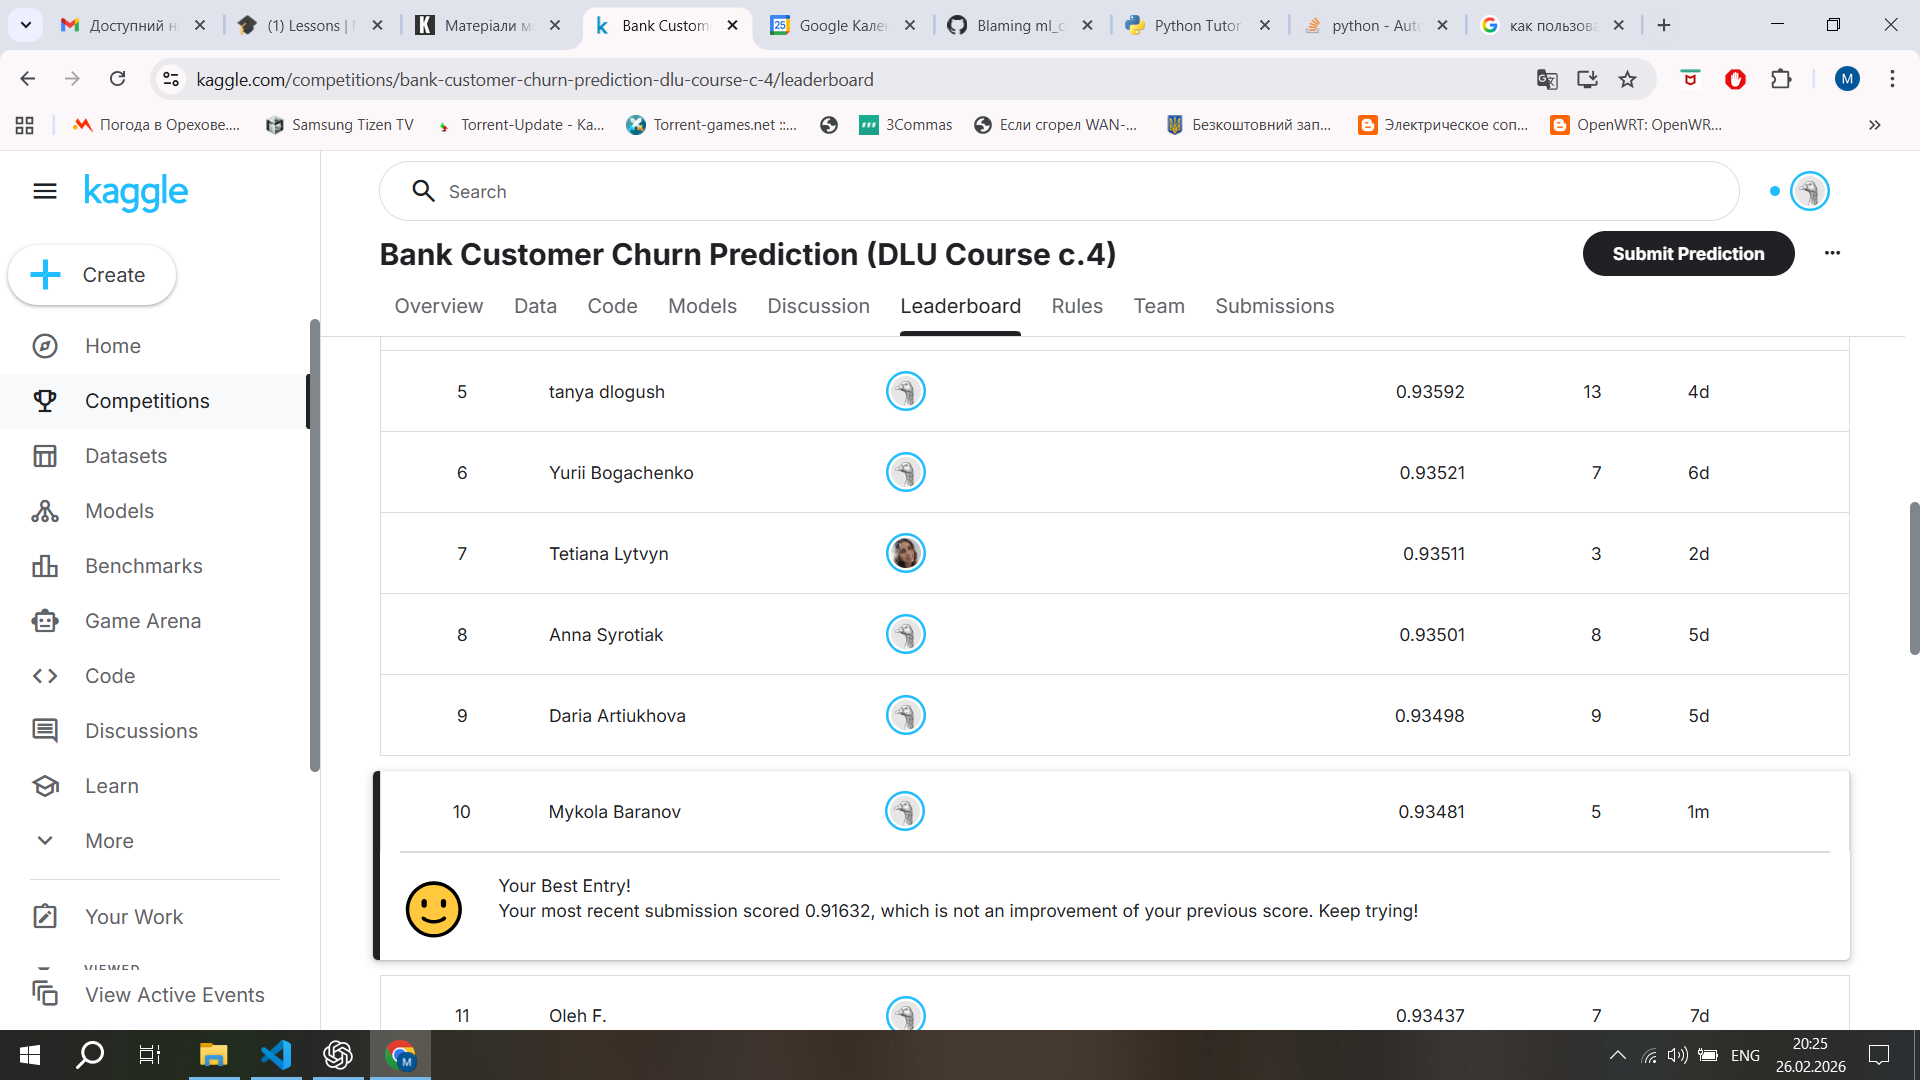